In [1]:
import pandas as pd

df = pd.read_csv("/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/raw/uncleaned-ds-jobs-6992efeeb7cba766418597.csv")
df.head()


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [2]:
df.info(5)

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       672 non-null    str    
 8   Size               672 non-null    str    
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    str    
 11  Industry           672 non-null    str    
 12  Sector             672 non-null    str    
 13  Revenue            672 non-null    str    
 14  Competitors        672 non-null    str    
dtypes: float64(1), int64(2), str(12)
memory usage: 78.9 KB


In [3]:
list_df=["Job Title", "Salary Estimate","Job Description", "Company Name", "Location", "Headquarters",
         "Size", "Type of ownership", "Industry", "Sector", "Revenue", "Competitors"]

for col in list_df:
    print(df[col].value_counts())

Job Title
Data Scientist                                                      337
Data Engineer                                                        26
Senior Data Scientist                                                19
Machine Learning Engineer                                            16
Data Analyst                                                         12
                                                                   ... 
Sr. Research Associate/ Scientist, NGS prep & Molecular Genomics      1
Developer III - Data Science                                          1
Hydrogen/Tritium Materials Scientist (Experienced)                    1
Data Scientist/Data Analytics Practitioner                            1
AI/ML - Machine Learning Scientist, Siri Understanding                1
Name: count, Length: 172, dtype: int64
Salary Estimate
$75K-$131K (Glassdoor est.)     32
$79K-$131K (Glassdoor est.)     32
$99K-$132K (Glassdoor est.)     32
$137K-$171K (Glassdoor est.)    30
$90

In [4]:
df.describe()

,index,Rating,Founded
count,672.000000,672.000000,672.000000
mean,335.500000,3.518601,1635.529762
std,194.133974,1.410329,756.746640
min,0.000000,-1.000000,-1.000000
25%,167.750000,3.300000,1917.750000
50%,335.500000,3.800000,1995.000000
75%,503.250000,4.300000,2009.000000
max,671.000000,5.000000,2019.000000


On remarque des valeurs anormales (-1) dans Rating et Founded, ce qui indique que le dataset nécessite un nettoyage avant analyse

/var/folders/dl/577b_nr10wl3sq2rzk9_mgt00000gn/T/ipykernel_54409/424529304.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


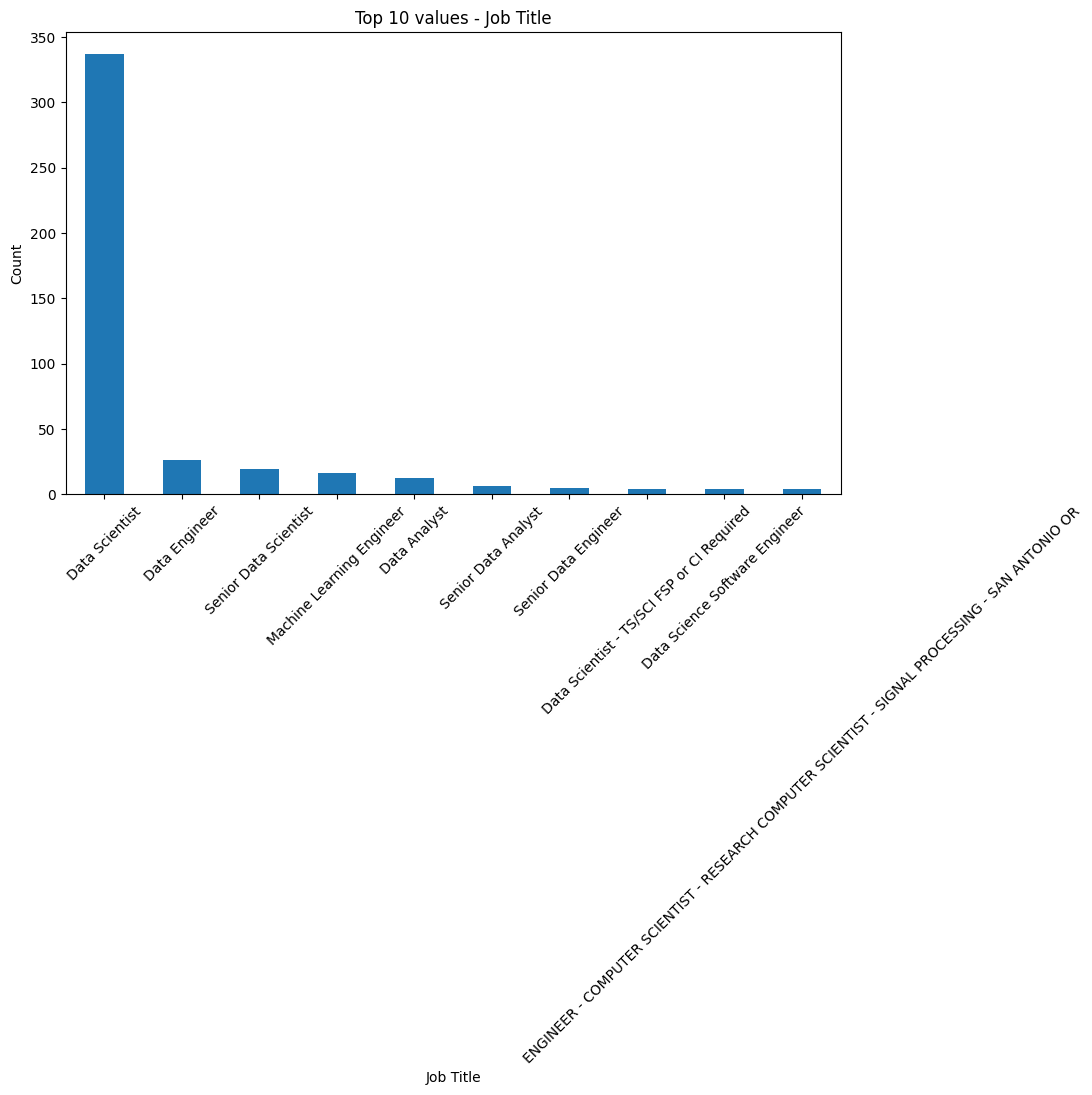

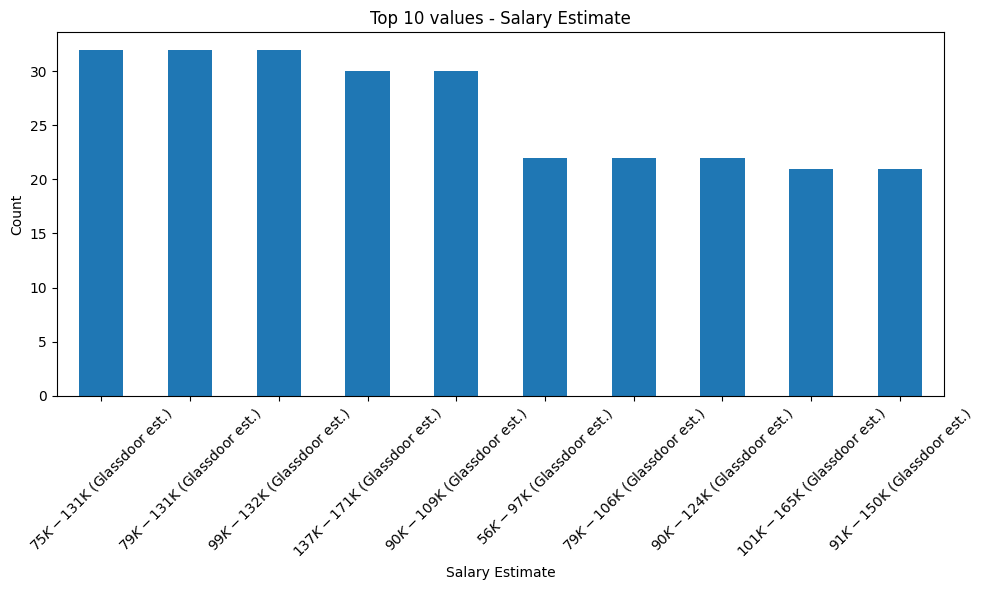

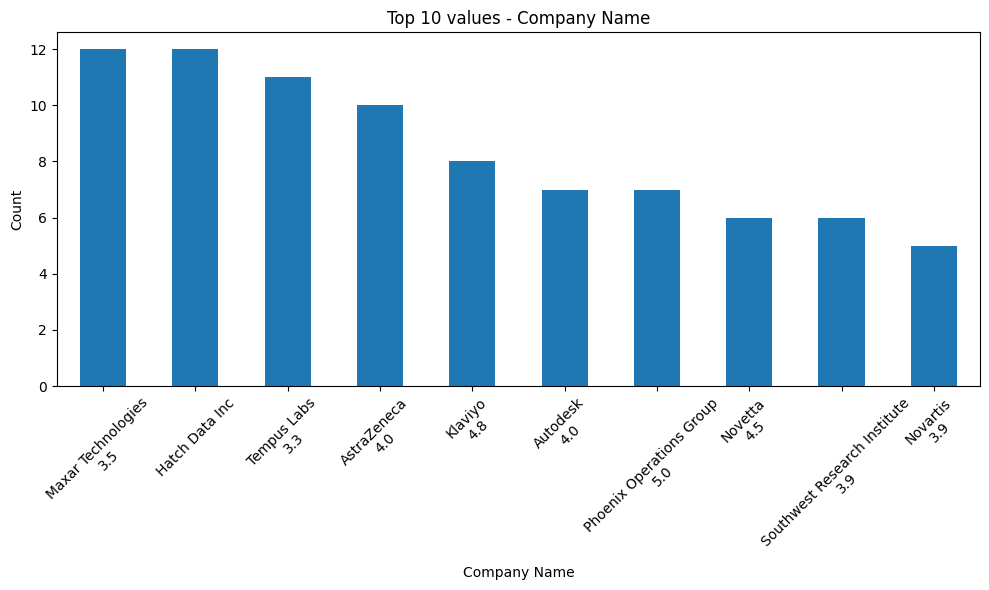

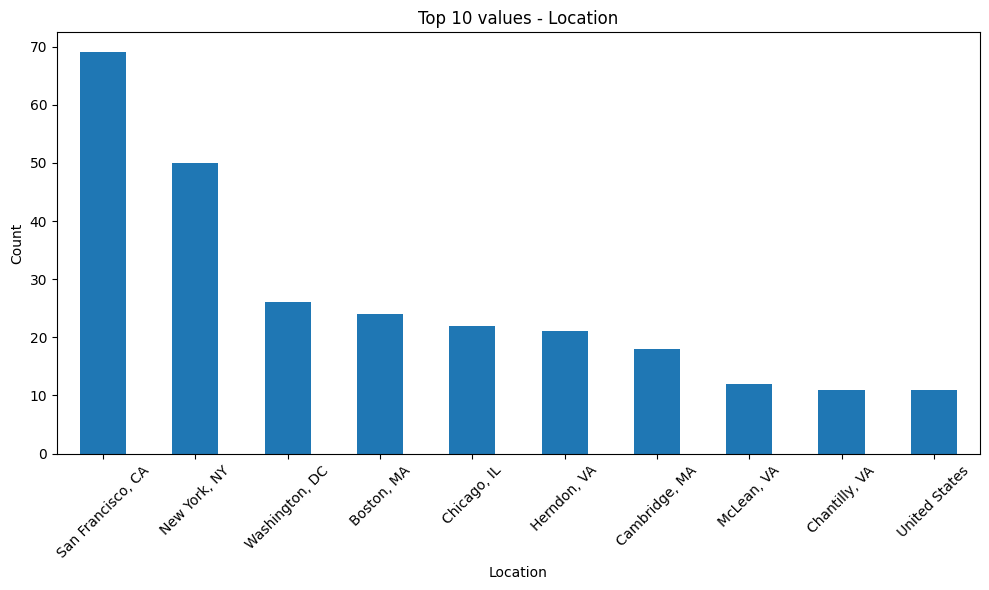

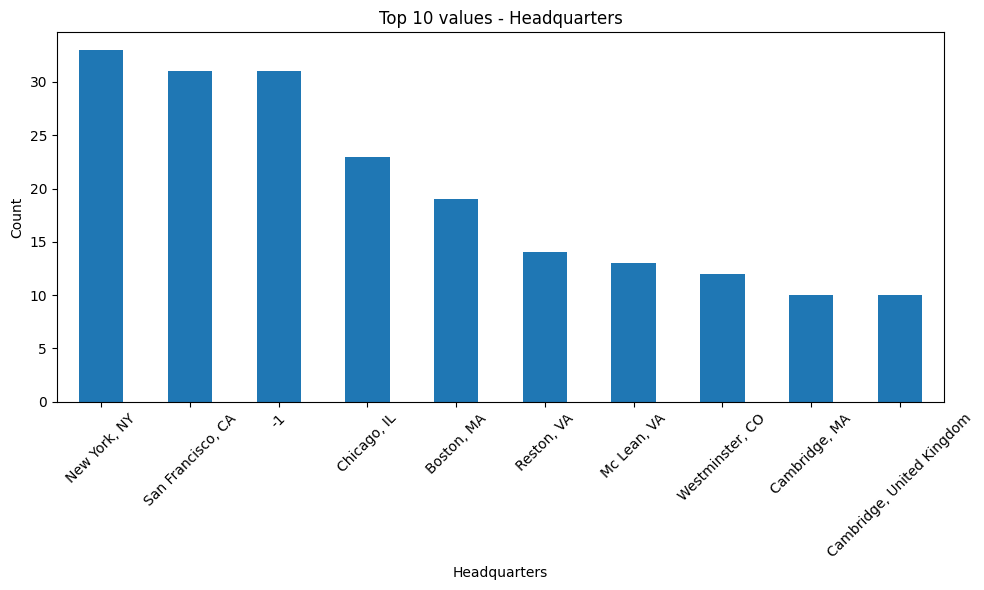

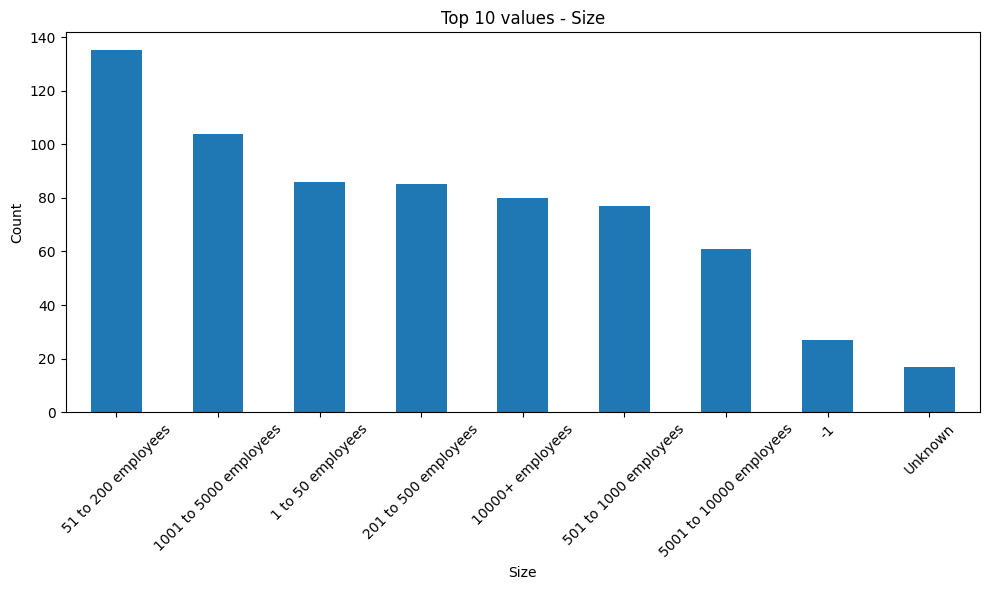

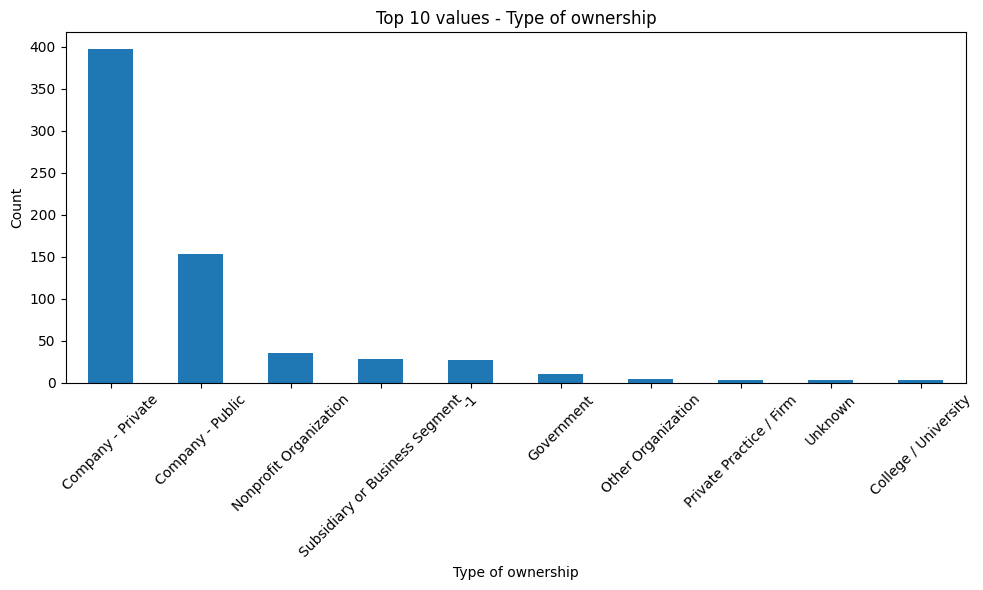

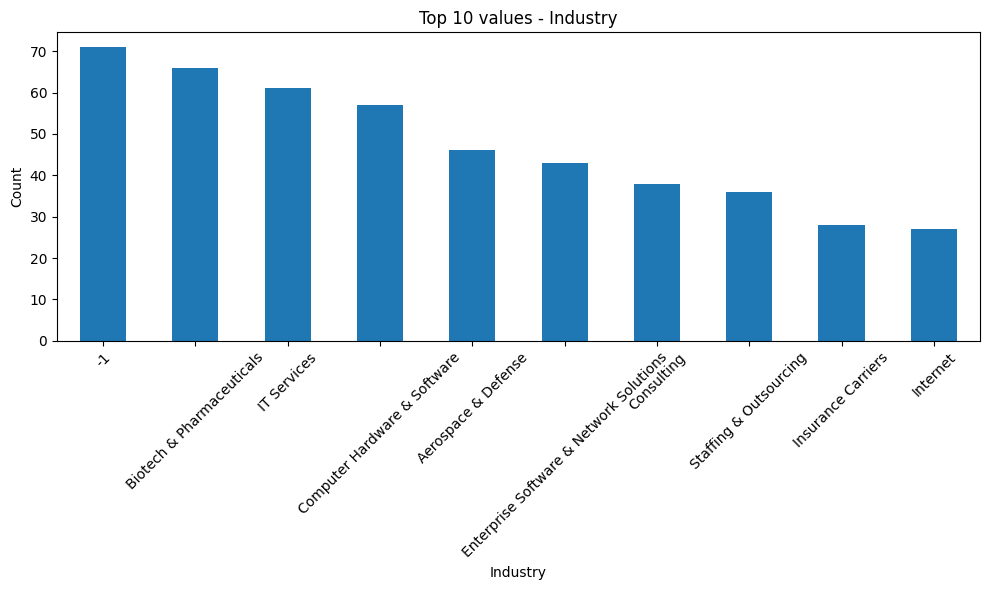

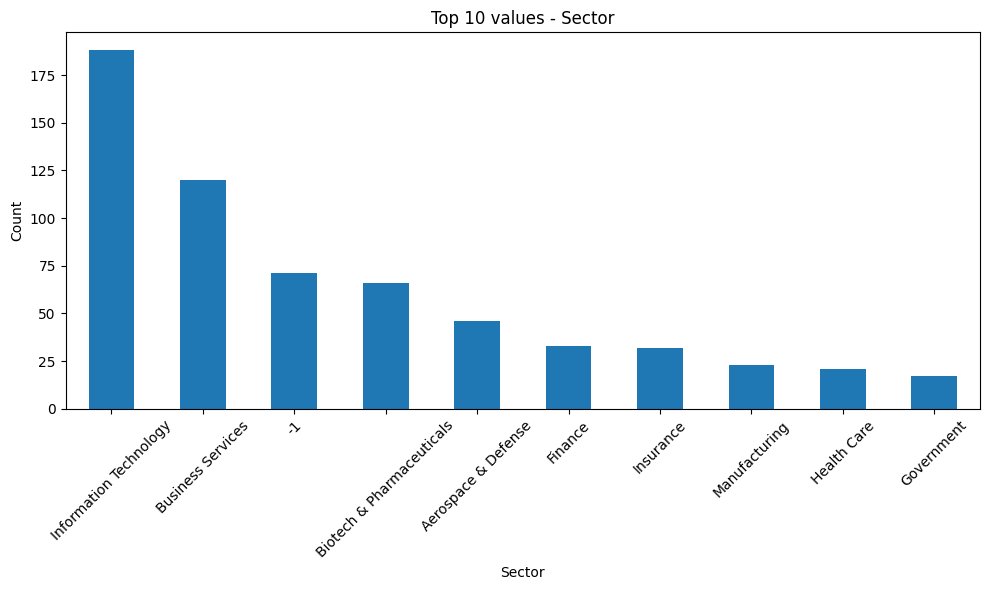

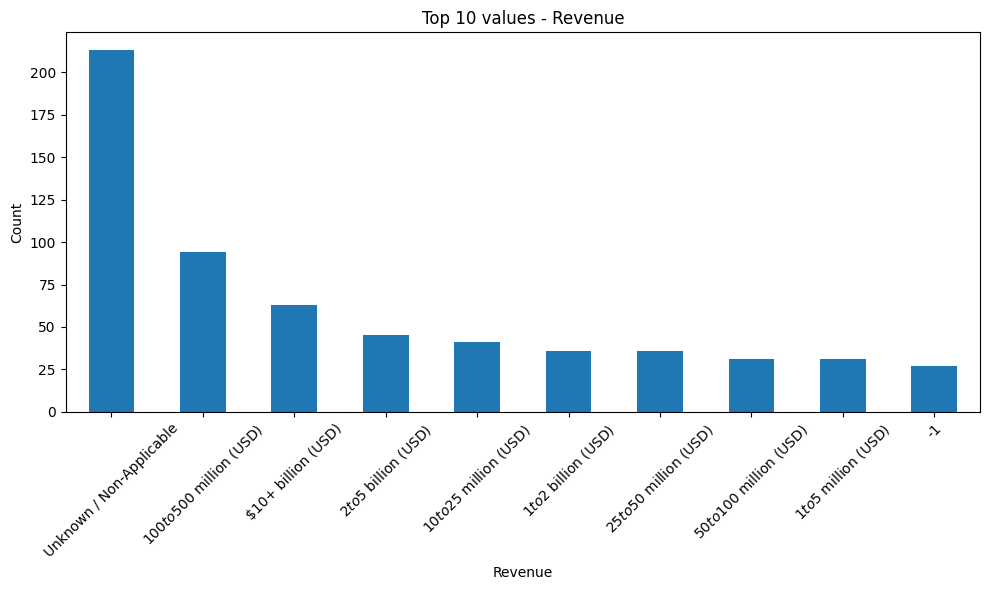

In [5]:
import matplotlib.pyplot as plt

cat_cols =["Job Title", "Salary Estimate", "Company Name", "Location", "Headquarters",
         "Size", "Type of ownership", "Industry", "Sector", "Revenue"]

for col in cat_cols:
    top_values = df[col].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    top_values.plot(kind="bar")
    plt.title(f"Top 10 values - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(numeric_cols)

['index', 'Rating', 'Founded']


In [15]:
import pandas as pd

numeric_cols = ['Rating'] 

def outliers(df, numeric_cols):
    result = []

    for col in numeric_cols:
        # Calcul des quantiles
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Bornes pour les outliers
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # détecter les outliers
        outlier_rows = df[(df[col] < lower) | (df[col] > upper)]

        # ajouter les résultats
        result.append({
            "column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "Outlier_Count": outlier_rows.shape[0],
            "Outliers": outlier_rows[col].tolist()
        })

    return pd.DataFrame(result)

# Lancer la détection
outliers_df = outliers(df, numeric_cols)
print(outliers_df)


   column   Q1   Q3  IQR  lower_bound  upper_bound  Outlier_Count  \
0  Rating  3.3  4.3  1.0          1.8          5.8             50   

                                            Outliers  
0  [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....  
